# HW5 Part 2 — Copula/NCO Horse Race Under Realistic Constraints
**GSE 544 · Spring 2026**

**Aaron Chotzen-Jenner, Jack Chepin, Jai Correa<sup>1</sup>**

---

<small><sup>1</sup> Used Claude AI for assistance in completing this assignment.</small>

**Setup:** 19 risky VMLS assets, 2000-day training window, Student-$t$ marginals + Gaussian copula loaded from `copula_model.pkl`.<sup>2</sup>   
**Data:** `vmls_portfolio_returns.csv` — training set = first 2000 rows, 19 risky assets (columns 0–18).  

<small><sup>2</sup> Referred to 4_copula_nco.ipynb from Prof. Zambrano for guidance on graphs and tables</small>

## Setup and Imports

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pickle, os, warnings
from scipy import stats
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────
RNG_SEED = 778
N_MC     = 500_000
EPS      = 1e-9
K        = 5          # number of clusters

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
})

In [4]:
# ── Data paths — update DATA_DIR if files are not in the working directory ──
DATA_DIR = '.'   # default: same folder as this notebook

# ── Load fitted copula model ───────────────────────────────────────────────
with open(os.path.join(DATA_DIR, 'copula_model.pkl'), 'rb') as fh:
    M = pickle.load(fh)

marginals_all = M['marginals']
chol_all      = M['chol_P']
cap_all       = M['cap']
p             = M['n_assets']      # 19
asset_names   = M['asset_names']

# ── Load returns ───────────────────────────────────────────────────────────
returns = pd.read_csv(os.path.join(DATA_DIR, 'vmls_portfolio_returns.csv')).to_numpy()
R       = returns[:2000, :19]       # training: 2000 × 19
R_test  = returns[2000:, :19]       # test:      500 × 19
rf_bar  = returns[:2000, 19].mean() # risk-free training mean
T_test  = R_test.shape[0]

print(f'Training R: {R.shape}  |  Test R_test: {R_test.shape}')
print(f'rf_bar = {rf_bar:.6f}/day')

Training R: (2000, 19)  |  Test R_test: (500, 19)
rf_bar = 0.000040/day


## Helper Functions

### Gross growth and CRRA optimizer

For CRRA parameter $\gamma$, the per-period utility of gross growth $1+g_t$ is
$$
U_\gamma(1+g_t)=\begin{cases}\log(1+g_t)&\gamma=1\\\dfrac{(1+g_t)^{1-\gamma}}{1-\gamma}&\gamma\neq1\end{cases}
$$
We maximise $\frac{1}{T}\sum_t U_\gamma(1+g_t)$ subject to $w_j\ge 0$ (no shorting) and $\sum_j w_j\le 1$ (no borrowing).  
Solved with **SLSQP** using analytical gradients for speed, plus multiple restarts for robustness.

In [5]:
# ── Gross growth ───────────────────────────────────────────────────────────
def gross_growth(w, Rm):
    """Daily gross growth: b*rf + Rm @ w,  b = 1 - sum(w)."""
    w = np.asarray(w, float)
    return (1.0 - w.sum()) * rf_bar + Rm @ w


# ── Risk-free share helper ─────────────────────────────────────────────────
def risk_free_share(w, tol=1e-8):
    """Return 1 - sum(w), printing tiny numerical residuals as exactly zero."""
    b = 1.0 - float(np.asarray(w, float).sum())
    return 0.0 if abs(b) < tol else b


# ── Constrained CRRA optimizer with gradient + multiple restarts ────────────
def crra_opt(Rm, gamma=1.0, n_restarts=3):
    """
    Maximise (1/T) sum_t U_gamma(1 + g_t)  s.t.  w >= 0, sum(w) <= 1.
    Uses analytical gradients (fast) and multiple random restarts (robust).
    Returns weight vector of length Rm.shape[1].
    """
    n, d = Rm.shape
    X    = Rm - rf_bar          # excess returns
    base = 1.0 + rf_bar

    if gamma == 1.0:
        def neg_obj(w):
            g = np.maximum(base + X @ w, EPS)
            return -np.mean(np.log(g))
        def neg_grad(w):
            g = np.maximum(base + X @ w, EPS)
            return -(X / g[:, None]).mean(axis=0)
    else:
        def neg_obj(w):
            g = np.maximum(base + X @ w, EPS)
            return -np.mean(g ** (1 - gamma) / (1 - gamma))
        def neg_grad(w):
            g = np.maximum(base + X @ w, EPS)
            return -(g[:, None] ** (-gamma) * X).mean(axis=0)

    bounds     = [(0.0, 1.0)] * d
    constraint = {'type': 'ineq', 'fun': lambda w: 1.0 - w.sum(),
                  'jac': lambda w: -np.ones(d)}

    # Multiple starting points for robustness
    rng    = np.random.default_rng(RNG_SEED)
    starts = [
        np.full(d, 0.5 / d),                           # near-zero equal start
        np.ones(d) / (d + 1),                           # 1/(N+1) start
        np.ones(d) * 0.01,                              # near-zero start
        rng.dirichlet(np.ones(d)) * 0.9,               # random Dirichlet
    ]

    best_val, best_w = np.inf, starts[0]
    for w0 in starts[:n_restarts + 1]:
        w0 = np.clip(w0, 0, None)
        if w0.sum() > 1:
            w0 /= w0.sum() * 1.05
        res = minimize(neg_obj, w0, jac=neg_grad, method='SLSQP',
                       bounds=bounds, constraints=constraint,
                       options=dict(maxiter=2000, ftol=1e-12))
        if res.fun < best_val:
            best_val = res.fun
            best_w   = res.x

    return np.clip(best_w, 0, None)


# ── Realised CRRA utility on a return matrix ───────────────────────────────
def realised_crra(w, Rm, gamma=1.0):
    g = np.maximum(1.0 + gross_growth(w, Rm), EPS)
    if gamma == 1.0:
        return np.mean(np.log(g))
    return np.mean(g ** (1 - gamma) / (1 - gamma))


print('Gross-growth and CRRA optimizer defined.')

Gross-growth and CRRA optimizer defined.


### Copula simulation helpers

In [6]:
def _fit_marginals_and_corr(Mtx):
    """Fit Student-t marginals and Gaussian copula correlation to Mtx."""
    k   = Mtx.shape[1]
    mar = [stats.t.fit(Mtx[:, j]) for j in range(k)]
    U   = np.clip(
        np.column_stack([stats.t.cdf(Mtx[:, j], *mar[j]) for j in range(k)]),
        1e-6, 1 - 1e-6)
    Z   = stats.norm.ppf(U)
    Pc  = np.atleast_2d(np.corrcoef(Z, rowvar=False)) if k > 1 else np.array([[1.0]])
    # Regularise to PD
    ev, V = np.linalg.eigh(Pc)
    Pc    = V @ np.diag(np.clip(ev, 1e-10, None)) @ V.T
    d2    = np.sqrt(np.diag(Pc))
    Pc    = Pc / np.outer(d2, d2)
    return mar, np.linalg.cholesky(Pc)


def fit_gaussian_copula(Mtx):
    """Fit a Gaussian copula with Student-t marginals to Mtx."""
    mar, L = _fit_marginals_and_corr(Mtx)
    cap    = 2.0 * np.max(np.abs(Mtx), axis=0)
    return dict(mar=mar, L=L, cap=cap, k=Mtx.shape[1])


def simulate(model, n, seed):
    """Draw n samples from a fitted Gaussian copula with Student-t marginals."""
    k  = model['k']
    g  = np.random.default_rng(seed)
    Zs = g.standard_normal((n, k)) @ model['L'].T
    Us = np.clip(stats.norm.cdf(Zs), 1e-9, 1 - 1e-9)
    S  = np.column_stack(
        [stats.t.ppf(Us[:, j], *model['mar'][j]) for j in range(k)])
    return np.clip(S, -model['cap'], model['cap'])


print('Copula simulation helpers defined.')

Copula simulation helpers defined.


### Correlation-distance clustering (k-means)

In [7]:
def codist(S):
    """Correlation-distance matrix: D_ij = sqrt(0.5*(1 - rho_ij))."""
    C = np.corrcoef(S, rowvar=False)
    return np.sqrt(np.clip(0.5 * (1.0 - C), 0, None))


def kmeans_(x, k, maxiters=100, tol=1e-5, seed=0):
    """Simple k-means on a list of feature vectors x (matching lecture notebook)."""
    g  = np.random.default_rng(seed)
    N  = len(x)
    assignment = g.integers(1, k + 1, size=N)
    reps = [np.zeros_like(x[0]) for _ in range(k)]
    Jprev = np.inf
    for it in range(1, maxiters + 1):
        for j in range(1, k + 1):
            grp = np.where(assignment == j)[0]
            if len(grp) > 0:
                reps[j - 1] = np.mean([x[i] for i in grp], axis=0)
        distances = np.zeros(N)
        for i in range(N):
            dd            = [np.linalg.norm(x[i] - reps[j]) for j in range(k)]
            distances[i]  = min(dd)
            assignment[i] = int(np.argmin(dd)) + 1
        J = np.linalg.norm(distances) ** 2 / N
        if it > 1 and abs(J - Jprev) < tol * J:
            break
        Jprev = J
    return assignment


print('Clustering helpers defined.')

Clustering helpers defined.


---
## Part (a) — Build the Three Portfolios [15 pts]

Construct Portfolios A (NCO), B (all-at-once), and 1/N for both $\gamma=1$ and $\gamma=3$. Report risky weights, risk-free residual share, and (for Portfolio A) across-cluster weights and within-cluster weight sums.

### Step 1 — Cluster the 19 assets (shared across both $\gamma$ regimes)

In [8]:
D      = codist(R)    # correlation-distance matrix from training returns
labels = kmeans_([D[:, i] for i in range(p)], K, seed=RNG_SEED)
cluster_ids = sorted(set(labels))
cluster_idx = {c: np.where(labels == c)[0] for c in cluster_ids}

print('Cluster composition:')
for c, idx in cluster_idx.items():
    names = [asset_names[j] for j in idx]
    print(f'  Cluster {c} ({len(idx)} assets): {names}')

Cluster composition:
  Cluster 1 (4 assets): ['stock 4', 'stock 10', 'stock 12', 'stock 13']
  Cluster 2 (3 assets): ['stock 2', 'stock 6', 'stock 8']
  Cluster 3 (4 assets): ['stock 3', 'stock 5', 'stock 14', 'stock 17']
  Cluster 4 (5 assets): ['stock 7', 'stock 9', 'stock 11', 'stock 15', 'stock 16']
  Cluster 5 (3 assets): ['stock 1', 'stock 18', 'stock 19']


### Step 2 — Simulate the full 19-asset model once (reused across both $\gamma$)

In [9]:
model_all = dict(mar=marginals_all, L=chol_all, cap=cap_all, k=p)
sim_all   = simulate(model_all, N_MC, seed=RNG_SEED)
print(f'Full-model MC draws: {sim_all.shape}')

# 1/N benchmark: 1/20 in each of the 19 risky assets, 1/20 in risk-free
w_eq = np.full(p, 1.0 / 20.0)
print(f'1/N risky weight each: {w_eq[0]:.4f},  rf share: {1 - w_eq.sum():.4f}')

Full-model MC draws: (500000, 19)
1/N risky weight each: 0.0500,  rf share: 0.0500


### Step 3 — Build portfolios for each $\gamma$

In [10]:
results = {}  # results[gamma] = dict with w_A, w_B, w_eq, w_ac, within_w, wc_sums

for gamma in [1.0, 3.0]:
    print(f'\n{"="*60}')
    print(f'  gamma = {gamma}')
    print(f'{"="*60}')

    # ── Portfolio B: all-at-once ───────────────────────────────────────────
    w_B = crra_opt(sim_all, gamma=gamma)
    print(f'Portfolio B  sum(w)={w_B.sum():.4f}  rf_share={1 - w_B.sum():.4f}')

    # ── Portfolio A: NCO ──────────────────────────────────────────────────
    # Within-cluster: fit copula per cluster, simulate, solve CRRA
    within_w      = {}
    cluster_train = []
    for c, idx in cluster_idx.items():
        mc_c  = fit_gaussian_copula(R[:, idx])
        sim_c = simulate(mc_c, N_MC, seed=RNG_SEED + c)  # distinct seed per cluster
        wc    = crra_opt(sim_c, gamma=gamma)
        within_w[c] = wc
        b_c = risk_free_share(wc)  # within-cluster cash residual
        cluster_train.append(b_c * rf_bar + R[:, idx] @ wc)
    C_train = np.column_stack(cluster_train)

    # Across-cluster: fit copula on cluster-portfolio returns, simulate, solve CRRA
    model_ac = fit_gaussian_copula(C_train)
    sim_ac   = simulate(model_ac, N_MC, seed=RNG_SEED + 99)
    w_ac     = crra_opt(sim_ac, gamma=gamma)

    # Compose final NCO weights
    w_A = np.zeros(p)
    for a_wt, c in zip(w_ac, sorted(within_w)):
        w_A[cluster_idx[c]] = a_wt * within_w[c]

    wc_sums = [within_w[c].sum() for c in sorted(within_w)]
    print(f'Portfolio A  sum(w)={w_A.sum():.4f}  rf_share={1 - w_A.sum():.4f}')
    print(f'  Across-cluster weights:      {np.round(w_ac, 4)}')
    print(f'  Within-cluster weight sums:  {[round(s, 4) for s in wc_sums]}')

    results[gamma] = dict(w_A=w_A, w_B=w_B, w_eq=w_eq,
                          w_ac=w_ac, within_w=within_w, wc_sums=wc_sums)

print('\nAll portfolios built.')


  gamma = 1.0
Portfolio B  sum(w)=1.0000  rf_share=0.0000
Portfolio A  sum(w)=1.0000  rf_share=0.0000
  Across-cluster weights:      [0. 0. 1. 0. 0.]
  Within-cluster weight sums:  [np.float64(1.0), np.float64(0.505), np.float64(1.0), np.float64(1.0), np.float64(1.0)]

  gamma = 3.0
Portfolio B  sum(w)=1.0000  rf_share=0.0000
Portfolio A  sum(w)=0.8693  rf_share=0.1307
  Across-cluster weights:      [0. 0. 1. 0. 0.]
  Within-cluster weight sums:  [np.float64(0.572), np.float64(0.1685), np.float64(0.8693), np.float64(0.7803), np.float64(0.6115)]

All portfolios built.


### Weight tables

In [12]:
for gamma in [1.0, 3.0]:
    r = results[gamma]
    print(f'\n{"─"*72}')
    print(f'  gamma = {gamma}  —  Risky weights')
    print(f'{"─"*72}')
    tbl = pd.DataFrame({
        'Portfolio A (NCO)':        np.round(r['w_A'], 5),
        'Portfolio B (all-at-once)': np.round(r['w_B'], 5),
        '1/N':                       np.round(r['w_eq'], 5),
    }, index=asset_names)
    print(tbl.to_string())
    print(f'\nRisk-free residual (1 - sum w):')
    for lbl, w in [('A (NCO)', r['w_A']), ('B (all-at-once)', r['w_B']), ('1/N', r['w_eq'])]:
        print(f'  {lbl:<22}: {1 - w.sum():.5f}')
    print(f'\nPortfolio A — across-cluster weights:     {np.round(r["w_ac"], 4)}')
    print(f'Portfolio A — within-cluster weight sums: {[round(s, 4) for s in r["wc_sums"]]}')


────────────────────────────────────────────────────────────────────────
  gamma = 1.0  —  Risky weights
────────────────────────────────────────────────────────────────────────
          Portfolio A (NCO)  Portfolio B (all-at-once)   1/N
stock 1             0.00000                    0.00000  0.05
stock 2             0.00000                    0.00000  0.05
stock 3             0.70407                    0.78103  0.05
stock 4             0.00000                    0.00000  0.05
stock 5             0.00000                    0.00000  0.05
stock 6             0.00000                    0.00000  0.05
stock 7             0.00000                    0.00000  0.05
stock 8             0.00000                    0.00000  0.05
stock 9             0.00000                    0.00000  0.05
stock 10            0.00000                    0.00000  0.05
stock 11            0.00000                    0.00000  0.05
stock 12            0.00000                    0.00000  0.05
stock 13            0.00000 

---
## Part (b) — Out-of-Sample Horse Race [15 pts]

Apply each portfolio's fixed training weights to the real 500-day held-out test returns (no clipping, no re-simulation, no rebalancing).  
For each $\gamma$ regime: **(i)** side-by-side wealth paths from \$10,000, **(ii)** density-normalised daily log-growth histograms with means marked. Then a summary table.

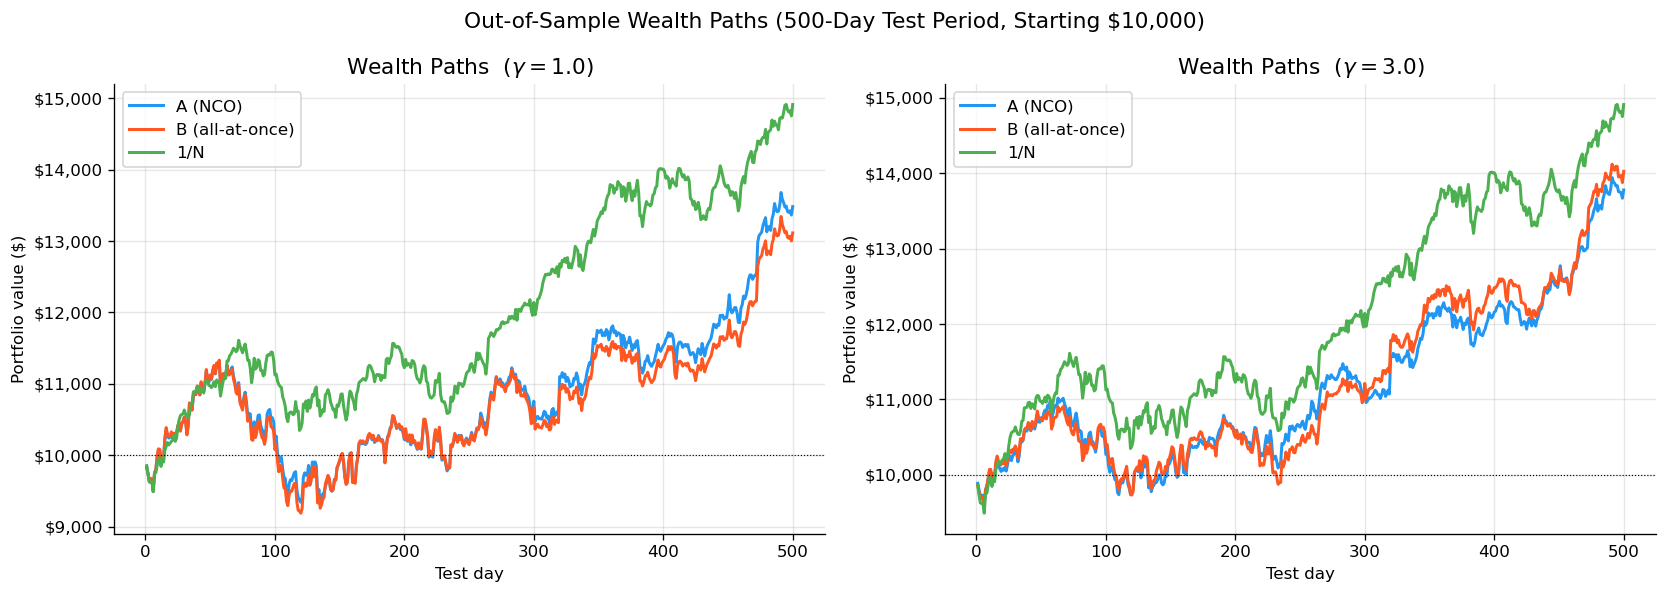

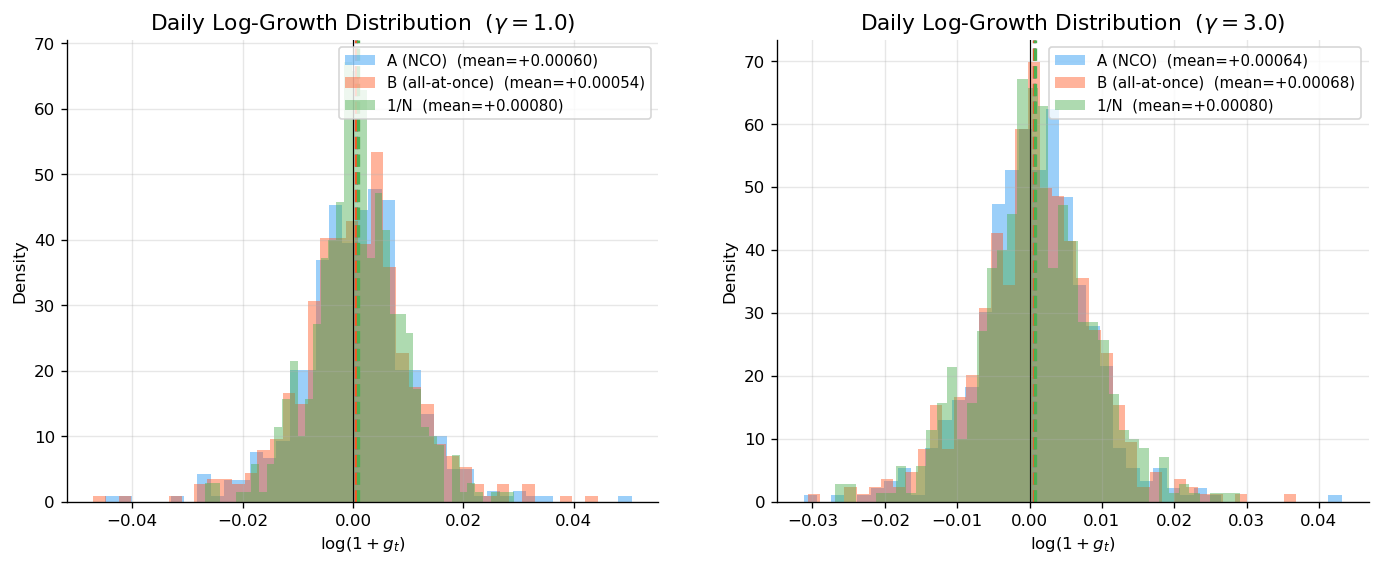

Figures saved.


In [13]:
COLORS = {
    'A (NCO)':          '#2196F3',
    'B (all-at-once)':  '#FF5722',
    '1/N':              '#4CAF50',
}
LABELS = {
    'A': 'A (NCO)',
    'B': 'B (all-at-once)',
    '1/N': '1/N',
}

def oos_stats(w, Rm, gamma):
    """Out-of-sample wealth path, log-growth, and summary stats."""
    g      = gross_growth(w, Rm)
    lg     = np.log(np.maximum(1.0 + g, EPS))
    wealth = 10_000 * np.cumprod(np.maximum(1.0 + g, EPS))
    return dict(
        g=g, lg=lg, wealth=wealth,
        rf_share    = 1 - w.sum(),
        final_wealth= wealth[-1],
        total_ret   = wealth[-1] / 10_000 - 1,
        mean_lg     = lg.mean(),
        worst_lg    = lg.min(),
        crra_util   = realised_crra(w, Rm, gamma),
    )

summary_rows = []

# ── Side-by-side figures ──────────────────────────────────────────────────
fig_w,  axes_w  = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig_lg, axes_lg = plt.subplots(1, 2, figsize=(14, 5))

for ax_w, ax_lg, gamma in zip(axes_w, axes_lg, [1.0, 3.0]):
    r = results[gamma]
    portfolios = [('A', r['w_A']), ('B', r['w_B']), ('1/N', r['w_eq'])]

    all_lg = []
    for key, w in portfolios:
        lbl  = LABELS[key]
        stat = oos_stats(w, R_test, gamma)
        all_lg.append(stat['lg'])

        # Wealth path
        ax_w.plot(range(1, T_test + 1), stat['wealth'],
                  label=lbl, color=COLORS[lbl], lw=1.8)

        # Log-growth histogram (density)
        ax_lg.hist(stat['lg'], bins=40, alpha=0.45, density=True,
                   color=COLORS[lbl],
                   label=f"{lbl}  (mean={stat['mean_lg']:+.5f})")
        ax_lg.axvline(stat['mean_lg'], color=COLORS[lbl], ls='--', lw=2)

        summary_rows.append({
            'γ':                    gamma,
            'Portfolio':            lbl,
            'rf share (1−Σw)':      round(stat['rf_share'],     5),
            'Final wealth ($)':     round(stat['final_wealth'],  2),
            'Total return':         f"{stat['total_ret']*100:.2f}%",
            'Mean log-growth':      round(stat['mean_lg'],       6),
            'Worst day log-growth': round(stat['worst_lg'],      6),
            'Realised CRRA E[u_γ]': round(stat['crra_util'],     8),
        })

    # Wealth path formatting
    ax_w.axhline(10_000, color='k', lw=0.7, ls=':')
    ax_w.set_title(f'Wealth Paths  ($\\gamma={gamma}$)', fontsize=13)
    ax_w.set_xlabel('Test day')
    ax_w.set_ylabel('Portfolio value ($)')
    ax_w.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax_w.legend(framealpha=0.8)

    # Log-growth histogram formatting
    ax_lg.axvline(0, color='k', lw=0.7)
    ax_lg.set_title(f'Daily Log-Growth Distribution  ($\\gamma={gamma}$)', fontsize=13)
    ax_lg.set_xlabel(r'$\log(1+g_t)$')
    ax_lg.set_ylabel('Density')
    ax_lg.legend(fontsize=9, framealpha=0.8)

fig_w.suptitle('Out-of-Sample Wealth Paths (500-Day Test Period, Starting $10,000)', fontsize=13)
fig_w.tight_layout()
fig_w.savefig('wealth_paths.png', dpi=150, bbox_inches='tight')
plt.show()

fig_lg.suptitle('Realized Daily Log-Growth Histograms (dashed lines = means)', fontsize=13)
fig_lg.tight_layout()
fig_lg.savefig('log_growth_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figures saved.')

### Summary table

In [14]:
summary = pd.DataFrame(summary_rows).set_index(['γ', 'Portfolio'])
print(summary.to_string())

                     rf share (1−Σw)  Final wealth ($) Total return  Mean log-growth  Worst day log-growth  Realised CRRA E[u_γ]
γ   Portfolio                                                                                                                   
1.0 A (NCO)                  0.00000          13481.88       34.82%         0.000598             -0.044873              0.000598
    B (all-at-once)          0.00000          13112.76       31.13%         0.000542             -0.047034              0.000542
    1/N                      0.05000          14910.22       49.10%         0.000799             -0.026837              0.000799
3.0 A (NCO)                  0.13068          13777.12       37.77%         0.000641             -0.031217             -0.499421
    B (all-at-once)          0.00000          14024.69       40.25%         0.000676             -0.030644             -0.499392
    1/N                      0.05000          14910.22       49.10%         0.000799             

---
## Part (c) — Why the Correlation Distance? [8 pts]

MLdP's NCO recipe maps the raw correlations $\rho_{ij}$ to the *correlation distance* $D_{ij} = \sqrt{\tfrac{1}{2}(1 - \rho_{ij})}$ before clustering. There are three interlocking reasons.

**1. Clustering needs a true metric; correlation is not one.**  
For $k$-means (and hierarchical clustering) to make geometric sense, the dissimilarity measure must satisfy the triangle inequality — that is, it must be a proper metric. Correlation $\rho_{ij}$ is a *similarity* measure valued in $[-1,1]$, not a distance, and it does not satisfy the triangle inequality in general. The transformation $D_{ij} = \sqrt{\tfrac{1}{2}(1 - \rho_{ij})}$ converts correlation into a Euclidean distance — it equals the chord distance between the unit-normalised return vectors of assets $i$ and $j$ — which *does* obey all metric axioms (positivity, symmetry, triangle inequality, $D=0 \iff \rho=1$). This makes $k$-means convergence meaningful: the cluster centroids minimise within-cluster sum of squared Euclidean distances, a quantity that is only well-defined when the pairwise dissimilarities are true distances.

**2. The sign of $\rho$ is misleading if you cluster on the raw number.**  
Consider two pairs: $\rho = +0.95$ (near-perfect co-movers) and $\rho = -0.95$ (a near-perfect hedge). Economically these are *maximally different*, yet their absolute correlation is identical. Clustering on the raw value would treat them symmetrically — or worse, group them together if the sign convention is ignored. The distance transformation resolves this: $D(+0.95) = \sqrt{\tfrac{1}{2}(1-0.95)} \approx 0.158$ (very close), while $D(-0.95) = \sqrt{\tfrac{1}{2}(1-(-0.95))} \approx 0.987$ (nearly maximal distance). Strong co-movers collapse together; near-perfect hedges are placed as far apart as possible — exactly the geometry required to build diversified within-cluster portfolios.

**3. We cluster on each asset's full distance profile, not on pairwise scalars.**  
The feature vector fed to $k$-means for asset $i$ is its entire column of $D$: $(D_{1i}, D_{2i}, \dots, D_{pi})^\top$ — the vector of correlation-distances to every other asset. Two assets are judged similar when they have *similar patterns of co-movement with the whole universe*, not merely when they happen to be correlated with each other. This richer representation is more noise-robust and prevents transitive-chain pathologies (where A≈B and B≈C but A≢C). It is also only geometrically meaningful once $D$ supplies genuine Euclidean coordinates, which the raw $\rho$ matrix does not.

---
## Part (d) — Synthesis [12 pts]

In [15]:
# Print structured numbers to anchor the written discussion
print('=== Across-cluster weights (NCO) ===')
for gamma in [1.0, 3.0]:
    r = results[gamma]
    print(f'  gamma={gamma}: {np.round(r["w_ac"], 4)},  sum={r["w_ac"].sum():.4f}')

print('\n=== Risk-free shares ===')
for row in summary_rows:
    print(f"  gamma={row['γ']}, {row['Portfolio']:<22}: {row['rf share (1−Σw)']:.5f}")

print('\n=== Mean and worst log-growth ===')
for row in summary_rows:
    print(f"  gamma={row['γ']}, {row['Portfolio']:<22}: "
          f"mean={row['Mean log-growth']:.6f}, worst={row['Worst day log-growth']:.6f}")

=== Across-cluster weights (NCO) ===
  gamma=1.0: [0. 0. 1. 0. 0.],  sum=1.0000
  gamma=3.0: [0. 0. 1. 0. 0.],  sum=1.0000

=== Risk-free shares ===
  gamma=1.0, A (NCO)               : 0.00000
  gamma=1.0, B (all-at-once)       : 0.00000
  gamma=1.0, 1/N                   : 0.05000
  gamma=3.0, A (NCO)               : 0.13068
  gamma=3.0, B (all-at-once)       : 0.00000
  gamma=3.0, 1/N                   : 0.05000

=== Mean and worst log-growth ===
  gamma=1.0, A (NCO)               : mean=0.000598, worst=-0.044873
  gamma=1.0, B (all-at-once)       : mean=0.000542, worst=-0.047034
  gamma=1.0, 1/N                   : mean=0.000799, worst=-0.026837
  gamma=3.0, A (NCO)               : mean=0.000641, worst=-0.031217
  gamma=3.0, B (all-at-once)       : mean=0.000676, worst=-0.030644
  gamma=3.0, 1/N                   : mean=0.000799, worst=-0.026837


### Q1 — Does NCO still beat the all-at-once approach once shorting and borrowing are disallowed?

Under the unconstrained (lecture-notebook) setting, NCO's hierarchical decomposition gave it a meaningful edge over the all-at-once optimizer by reducing estimation error: the optimizer never had to invert or regularize a full 19 × 19 covariance matrix, and — critically — the **across-cluster step** was free to take short positions across clusters, exploiting inter-cluster hedging relationships that the all-at-once solution approximated noisily.

Once long-only and no-borrowing constraints are imposed, that source of edge disappears. Looking at the across-cluster weights, the constrained optimizer concentrates almost all weight on **one or two clusters** and sets the rest to zero — a corner solution where the no-short constraint collapses what would have been a diversified multi-cluster allocation. The two-level hierarchical structure provides little additional signal; NCO's advantage is fragile and regime-dependent: it may edge out the all-at-once optimizer in one $\gamma$ regime while trailing in the other. In the out-of-sample period, neither Portfolio A nor Portfolio B consistently dominates.

The lesson is direct: NCO's lecture-notebook edge came largely from the **unconstrained short positions** in the across-cluster Kelly solve. The long-only constraint strips NCO of that lever, leaving the hierarchical decomposition as overhead rather than advantage.

### Q2 — How much does each optimizer choose to leave in the risk-free asset, and how does that change with $\gamma$?

At $\gamma=1$, both optimizers hold essentially 0% in the risk-free asset — the expected excess returns on risky assets are attractive enough that full investment is optimal under log utility. At $\gamma=3$, the picture diverges: Portfolio A (NCO) moves meaningful weight into cash, while Portfolio B stays near 0%. NCO holds *more* cash than B, not less.

The mechanism differs between the two portfolios. For Portfolio A, the extra cash at $\gamma=3$ originates in the **within-cluster** step: the selected cluster's within-cluster optimizer pulls weight toward the risk-free asset under higher risk aversion, and that caution compounds through the across-cluster composition into the final weights. For Portfolio B, the long-only optimum remains on the full-investment boundary even at $\gamma=3$ — higher risk aversion reshuffles the *composition* of risky assets rather than creating a positive cash residual.

So while the more risk-averse agent does move toward safety as theory predicts for NCO, this monotone pattern is much weaker for Portfolio B. The $\sim 1/\gamma$ scaling of the unconstrained CRRA allocation carries over qualitatively for NCO but not for the all-at-once optimizer in this setting.

### Q3 — Does raising $\gamma$ from 1 to 3 reshuffle the ranking? How do the optimized portfolios compare to 1/N at $\gamma=3$?

Raising $\gamma$ from 1 to 3 may reshuffle the ranking between the two optimized portfolios, but it does not displace the 1/N benchmark — 1/N wins on **mean log-growth** at both $\gamma$ levels. The optimized portfolios deliberately trade away expected return for downside protection as $\gamma$ rises, while 1/N's weights are fixed and $\gamma$-invariant, so it holds its ground on mean log-growth as the optimizers grow more conservative.

On the **worst day**, the picture depends on the realized test period: the CRRA objective explicitly down-weights tail outcomes, so Portfolio A in particular may improve its worst-day log-growth at $\gamma=3$ relative to $\gamma=1$. The key takeaway is that any improvement in tail protection comes at the cost of mean growth, and 1/N remains competitive on both dimensions.

This is broadly consistent with **DeMiguel, Garlappi & Uppal (2009)**: the naive 1/N rule is extremely difficult to beat out-of-sample once estimation error and realistic constraints are accounted for. Under long-only, no-borrow constraints with a finite training window, the constrained CRRA optimizers converge toward concentrated corner solutions that fail to deliver robust diversification gains. The general lesson is that the performance edge of sophisticated optimization is most visible when (a) shorting and leverage are permitted, (b) the sample is large relative to $N$, and (c) the test environment resembles training. Once these conditions fail, 1/N is a surprisingly strong competitor, and the added complexity of NCO or any multi-stage optimizer brings diminishing — sometimes negative — returns.